<a href="https://colab.research.google.com/github/KDT-final-project-team4/Multi-Armed-Bandit/blob/main/Multi_Armed_Bandit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```
# ============================================================
# 4. 실험 실행
# ============================================================

# TRUE_MEANS에 설정한 각 머신의 확률에 따라 어떤 접근 방법을 택하면 좋을지 나뉜다.
TRUE_MEANS = [0.72, 0.75, 0.70, 0.80, 0.73]
N_STEPS    = 5000
env        = SlotMachine(TRUE_MEANS)

np.random.seed(42)

cumulative_random, counts_random       = run_experiment(RandomAgent(5), env, N_STEPS)
cumulative_greedy, counts_greedy       = run_experiment(GreedyAgent(5), env, N_STEPS)
cumulative_eg01,   counts_eg01         = run_experiment(EpsilonGreedyAgent(5, 0.1), env, N_STEPS)
cumulative_eg001,  counts_eg001        = run_experiment(EpsilonGreedyAgent(5, 0.01), env, N_STEPS)

```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 환경: 슬롯머신
# ============================================================
class SlotMachine:
    def __init__(self, true_means):
        self.true_means = true_means          # 각 머신의 진짜 평균
        self.n_machines = len(true_means)

    def pull(self, machine_idx):
        """선택한 머신에서 보상 샘플링 (정규분포 N(μ, 1))"""
        return np.random.normal(self.true_means[machine_idx], 1.0)

In [ ]:
# np.random.normal([0.72, 0.75, 0.70, 0.80, 0.73][0], 1.0)

for i in range(10):
    print(np.random.normal([0.72, 0.75, 0.70, 0.80, 0.73][0], 1.0))

-0.02528488615349922
1.4800072539015547
1.0502638338395724
-0.1311440441016044
2.5875231999890786
-0.20430755401375578
2.339149986638529
1.046434386832729
1.074696754481781
0.014598720527554288


In [ ]:
# ============================================================
# 2. 전략 (Agent)
# ============================================================
class RandomAgent:
    def __init__(self, n_machines):
        self.n_machines = n_machines # n=5

    def select(self, q_values, counts):
        return np.random.randint(self.n_machines)   # 완전 랜덤 선택

class GreedyAgent:
    def __init__(self, n_machines):
        self.n_machines = n_machines

    def select(self, q_values, counts):
        # 한 번도 안 당긴 머신 우선 탐색 → 이후 Q값 최대 머신 선택
        unvisited = np.where(counts == 0)[0]
        if len(unvisited) > 0:
            return unvisited[0]
        return np.argmax(q_values)

class EpsilonGreedyAgent:
    def __init__(self, n_machines, epsilon):
        self.n_machines = n_machines
        self.epsilon = epsilon

    def select(self, q_values, counts):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_machines)   # 탐색
        return np.argmax(q_values)                      # 활용

In [ ]:
# ============================================================
# RandomAgent 전략
# ============================================================

for i in range(5):
    print(np.random.randint(5))

3
4
0
4
4


In [ ]:
'''
class GreedyAgent:
    def __init__(self, n_machines):
        self.n_machines = n_machines

    def select(self, q_values, counts):
        # 한 번도 안 당긴 머신 우선 탐색 → 이후 Q값 최대 머신 선택
        unvisited = np.where(counts == 0)[0]
        if len(unvisited) > 0:
            return unvisited[0]
        return np.argmax(q_values)
'''
def praticeSelect(self, q_values, counts):
    # 한 번도 안 당긴 머신 우선 탐색 → 이후 Q값 최대 머신 선택
    unvisited = np.where(counts == 0)[0]
    if len(unvisited) > 0:
        return unvisited[0]
    return np.argmax(q_values)

print(f"==================전부 0일때==================")
praticeNdarray = np.zeros(5)
praticeUnvisited = np.where(praticeNdarray == 0)
print(f'praticeNdarray=np.zeros(5)의 값: {praticeNdarray}')
print(f'praticeUnvisited=np.where(praticeNdarray == 0)의 값: {praticeUnvisited}')
print(f'praticeUnvisited[0] 값: {praticeUnvisited[0]}')
print(f'최종 선택-방문하지 않은 머신의 인덱스: {praticeUnvisited[0]}')

print(f"==================1이 한개 추가되었을때==================")
praticeNdarray[0] = 1

print(f'praticeNdarray 값: {praticeNdarray}')
praticeUnvisited = np.where(praticeNdarray == 0)
print(f'praticeUnvisited=np.where(praticeNdarray == 0)의 값: {praticeUnvisited}')
print(f'praticeUnvisited[0] 값: {praticeUnvisited[0]}')

unvisited = praticeUnvisited[0]

print(f'최종 선택-방문하지 않은 머신의 인덱스: {unvisited[0]}')

==================전부 0일때==================
praticeNdarray=np.zeros(5)의 값: [0. 0. 0. 0. 0.]
praticeUnvisited=np.where(praticeNdarray == 0)의 값: (array([0, 1, 2, 3, 4]),)
praticeUnvisited[0] 값: [0 1 2 3 4]
최종 선택-방문하지 않은 머신의 인덱스: [0 1 2 3 4]
==================1이 한개 추가되었을때==================
praticeNdarray 값: [1. 0. 0. 0. 0.]
praticeUnvisited=np.where(praticeNdarray == 0)의 값: (array([1, 2, 3, 4]),)
praticeUnvisited[0] 값: [1 2 3 4]
최종 선택-방문하지 않은 머신의 인덱스: 1


In [ ]:
jumiArray = np.zeros(5)
jumiArray[3] = 5
jumiArray[1] = 2
jumiArray[2] = 3
jumiArray[0] = 1
jumiArray[4] = 7
jumiArray

array([1., 2., 3., 5., 7.])

In [ ]:
np.argmax(jumiArray)

np.int64(4)

In [ ]:
# ============================================================
# Greedy 방식 예제 코드
# ============================================================

TRUE_MEANS = [0.2, 0.5, 0.1, 0.8, 0.3]
env = SlotMachine(TRUE_MEANS)
agent = EpsilonGreedyAgent(5, 0.1)

n = env.n_machines
q_values = np.zeros(n)
counts   = np.zeros(n)

np.random.seed(42)

print(f"{'스텝':<5} {'선택 머신':<10} {'받은 보상':<12} {'Q값 변화'}")
print("-" * 70)

for step in range(1, 100):
    idx    = agent.select(q_values, counts)
    reward = env.pull(idx)

    counts[idx]   += 1
    q_old          = q_values[idx]
    q_values[idx] += (reward - q_values[idx]) / counts[idx]

    print(f"스텝{step:<3} | M{idx+1} 선택 | "
          f"보상: {reward:+.3f} | "
          f"Q[M{idx+1}]: {q_old:.3f} → {q_values[idx]:.3f}  "
          f"{' ← 첫 방문' if counts[idx] == 1 else ''}")

print("-" * 70)
print(f"\n최종 Q값:  {np.round(q_values, 3)}")
print(f"실제 평균: {TRUE_MEANS}")
print(f"선택 횟수: {counts.astype(int)}")

스텝    선택 머신      받은 보상        Q값 변화
----------------------------------------------------------------------
스텝1   | M1 선택 | 보상: -0.912 | Q[M1]: 0.000 → -0.912   ← 첫 방문
스텝2   | M2 선택 | 보상: +0.819 | Q[M2]: 0.000 → 0.819   ← 첫 방문
스텝3   | M5 선택 | 보상: +1.879 | Q[M5]: 0.000 → 1.879   ← 첫 방문
스텝4   | M2 선택 | 보상: +1.267 | Q[M2]: 0.819 → 1.043  
스텝5   | M5 선택 | 보상: +0.322 | Q[M5]: 1.879 → 1.101  
스텝6   | M5 선택 | 보상: -0.128 | Q[M5]: 1.101 → 0.691  
스텝7   | M4 선택 | 보상: +0.097 | Q[M4]: 0.000 → 0.097   ← 첫 방문
스텝8   | M2 선택 | 보상: -1.640 | Q[M2]: 1.043 → 0.149  
스텝9   | M5 선택 | 보상: +2.859 | Q[M5]: 0.691 → 1.233  
스텝10  | M3 선택 | 보상: +0.494 | Q[M3]: 0.000 → 0.494   ← 첫 방문
스텝11  | M5 선택 | 보상: +0.007 | Q[M5]: 1.233 → 0.988  
스텝12  | M5 선택 | 보상: +0.270 | Q[M5]: 0.988 → 0.868  
스텝13  | M5 선택 | 보상: +0.160 | Q[M5]: 0.868 → 0.767  
스텝14  | M5 선택 | 보상: +0.267 | Q[M5]: 0.767 → 0.705  
스텝15  | M5 선택 | 보상: +1.249 | Q[M5]: 0.705 → 0.765  
스텝16  | M5 선택 | 보상: +1.881 | Q[M5]: 0.765 → 0.877  
스텝17  | M5 선택 | 보상: -0.89

In [ ]:
# ============================================================
# Epsilon Greedy 방식 예제 코드
# ============================================================

np.random.seed(42)

agent = EpsilonGreedyAgent(5, 0.5)
env   = SlotMachine(TRUE_MEANS)

q_values = np.zeros(5)
counts   = np.zeros(5)

print(f"{'스텝':<5} {'랜덤값':<10} {'판정':<10} {'선택':<10} {'보상':<10} {'Q값 업데이트'}")
print("-" * 75)

for step in range(1, 50):
    rand_val = np.random.random()             # 0~1 랜덤값 먼저 뽑기

    if rand_val < 0.5:
        idx    = np.random.randint(5)         # 탐색
        mode   = "🎲 탐색"
    else:
        idx    = np.argmax(q_values)          # 활용
        mode   = "💡 활용"

    reward        = env.pull(idx)
    q_old         = q_values[idx]
    counts[idx]  += 1
    q_values[idx] += (reward - q_values[idx]) / counts[idx]

    print(f"스텝{step:<3} | "
          f"랜덤값: {rand_val:.2f} | "
          f"{mode} | "
          f"M{idx+1} 선택 | "
          f"보상: {reward:+.3f} | "
          f"Q[M{idx+1}]: {q_old:.3f} → {q_values[idx]:.3f}")

print("-" * 75)
print(f"\n최종 Q값:  {np.round(q_values, 3)}")
print(f"실제 평균: {TRUE_MEANS}")
print(f"선택 횟수: {counts.astype(int)}")

스텝    랜덤값        판정         선택         보상         Q값 업데이트
---------------------------------------------------------------------------
스텝1   | 랜덤값: 0.37 | 🎲 탐색 | M5 선택 | 보상: +0.844 | Q[M5]: 0.000 → 0.844
스텝2   | 랜덤값: 0.60 | 💡 활용 | M5 선택 | 보상: -0.315 | Q[M5]: 0.844 → 0.264
스텝3   | 랜덤값: 0.45 | 🎲 탐색 | M3 선택 | 보상: -1.911 | Q[M3]: 0.000 → -1.911
스텝4   | 랜덤값: 0.14 | 🎲 탐색 | M3 선택 | 보상: -0.393 | Q[M3]: -1.911 → -1.152
스텝5   | 랜덤값: 0.02 | 🎲 탐색 | M2 선택 | 보상: +0.733 | Q[M2]: 0.000 → 0.733
스텝6   | 랜덤값: 0.00 | 🎲 탐색 | M4 선택 | 보상: +0.918 | Q[M4]: 0.000 → 0.918
스텝7   | 랜덤값: 0.18 | 🎲 탐색 | M4 선택 | 보상: +0.822 | Q[M4]: 0.918 → 0.870
스텝8   | 랜덤값: 0.40 | 🎲 탐색 | M4 선택 | 보상: +0.372 | Q[M4]: 0.870 → 0.704
스텝9   | 랜덤값: 0.97 | 💡 활용 | M2 선택 | 보상: +0.249 | Q[M2]: 0.733 → 0.491
스텝10  | 랜덤값: 0.62 | 💡 활용 | M4 선택 | 보상: +0.636 | Q[M4]: 0.704 → 0.687
스텝11  | 랜덤값: 0.38 | 🎲 탐색 | M4 선택 | 보상: +0.256 | Q[M4]: 0.687 → 0.601
스텝12  | 랜덤값: 0.61 | 💡 활용 | M4 선택 | 보상: +0.911 | Q[M4]: 0.601 → 0.653
스텝13  | 랜덤값: 0.17 | 🎲 탐색 | M2 선택 | 

In [ ]:
# ============================================================
# 3. 실험 실행기
# ============================================================
def run_experiment(agent, env, n_steps=1000):
    n = env.n_machines
    q_values    = np.zeros(n)     # Q(a): 각 머신의 추정 보상 (0 초기화)
    counts      = np.zeros(n)     # 각 머신 선택 횟수
    cumulative  = []              # 누적 보상 기록

    total_reward = 0

    for step in range(n_steps):
        idx = agent.select(q_values, counts)        # 머신 선택
        reward = env.pull(idx)                      # 보상 받기

        # Q값 업데이트 (표본 평균)
        counts[idx] += 1
        q_values[idx] += (reward - q_values[idx]) / counts[idx]

        total_reward += reward
        cumulative.append(total_reward)

    return cumulative, counts


In [ ]:
np.zeros(5)

array([0., 0., 0., 0., 0.])

```
q_values[idx] += (reward - q_values[idx]) / counts[idx]

이게 점진적 평균 계산
```

```
새 Q값 = 이전 Q값 + (새 보상 - 이전 Q값) / 횟수

          ↑ 이전 평균에서       ↑ 오차만큼 조금씩 보정
```

In [ ]:
# ============================================================
# 4. 실험 실행
# ============================================================

# TRUE_MEANS에 설정한 각 머신의 확률에 따라 어떤 접근 방법을 택하면 좋을지 나뉜다.
TRUE_MEANS = [0.72, 0.55, 0.6, 0.77, 0.5]
N_STEPS    = 70000
env        = SlotMachine(TRUE_MEANS)

np.random.seed(42)

cumulative_random, counts_random       = run_experiment(RandomAgent(5), env, N_STEPS)
cumulative_greedy, counts_greedy       = run_experiment(GreedyAgent(5), env, N_STEPS)
cumulative_eg01,   counts_eg01         = run_experiment(EpsilonGreedyAgent(5, 0.1), env, N_STEPS)
cumulative_eg001,  counts_eg001        = run_experiment(EpsilonGreedyAgent(5, 0.01), env, N_STEPS)

In [ ]:
cumulative_random

[-0.3118801180469204,
 0.7070220666424629,
 -0.603940823102165,
 -0.3967442480655932,
 -0.2476223820891082,
 -0.042792189267255976,
 0.9191700822987781,
 -0.1941101623590198,
 1.3423349185923075,
 0.5684589209764466,
 1.5905378225411897,
 1.6225613205981126,
 1.87817859607293,
 2.689101185782796,
 3.1257020394241346,
 3.815863470064386,
 2.589143854334294,
 4.458567465896131,
 4.4394909424527755,
 4.461108935361882,
 4.727460131519395,
 5.441932269199269,
 6.80804509598031,
 6.85359164560372,
 7.872229961657582,
 9.553991000606192,
 10.537477040836402,
 12.929248156850477,
 13.992866446418939,
 12.949826291056205,
 14.261949085769244,
 15.8496975453626,
 15.710480022139961,
 16.121267646288747,
 16.442093408443455,
 16.98643443177964,
 16.112279144835583,
 17.450232088060474,
 18.497077312030488,
 19.1159583578718,
 18.90219551695975,
 20.386403704613688,
 20.491527945196378,
 21.62442038568531,
 22.504909463795904,
 23.111488212449512,
 25.7057690554581,
 27.016458597188127,
 26.32786

In [ ]:
counts_random

array([ 975.,  975., 1019.,  981., 1050.])

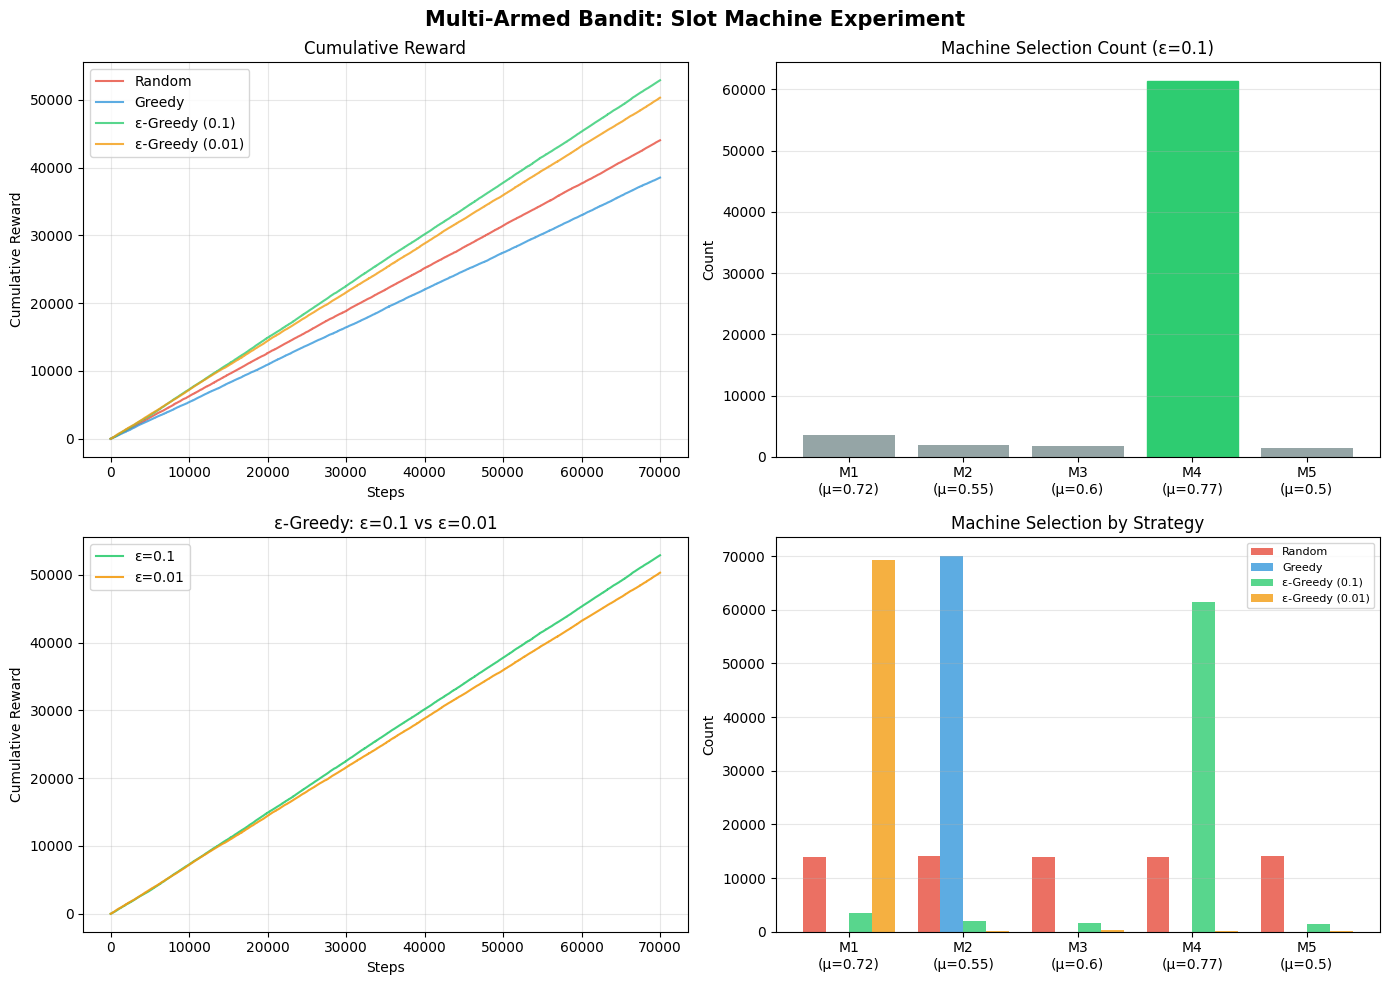

  최적 머신: M4 (μ=0.77)
  전략                   최종 누적 보상
---------------------------------------------
  Random               44020.34
  Greedy               38520.61
  ε-Greedy (ε=0.1)     52872.89
  ε-Greedy (ε=0.01)    50301.20


In [ ]:
# ============================================================
# 5. 시각화
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Multi-Armed Bandit: Slot Machine Experiment", fontsize=15, fontweight='bold')

steps   = range(1, N_STEPS + 1)
machine_labels = [f"M{i+1}\n(μ={m})" for i, m in enumerate(TRUE_MEANS)]
colors  = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# ── (1) 누적 보상 곡선: 전략 4개 비교 ──
ax1 = axes[0, 0]
ax1.plot(steps, cumulative_random, label='Random',          color=colors[0], alpha=0.8)
ax1.plot(steps, cumulative_greedy, label='Greedy',          color=colors[1], alpha=0.8)
ax1.plot(steps, cumulative_eg01,   label='ε-Greedy (0.1)',  color=colors[2], alpha=0.8)
ax1.plot(steps, cumulative_eg001,  label='ε-Greedy (0.01)', color=colors[3], alpha=0.8)
ax1.set_title("Cumulative Reward")
ax1.set_xlabel("Steps")
ax1.set_ylabel("Cumulative Reward")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── (2) 머신별 선택 횟수: ε-Greedy(0.1) 기준 ──
ax2 = axes[0, 1]
bars = ax2.bar(machine_labels, counts_eg01, color=['#95a5a6']*5)
bars[np.argmax(TRUE_MEANS)].set_color('#2ecc71')   # 최적 머신 강조
ax2.set_title("Machine Selection Count (ε=0.1)")
ax2.set_ylabel("Count")
ax2.grid(True, alpha=0.3, axis='y')

# ── (3) ε값 비교: 누적 보상 ──
ax3 = axes[1, 0]
ax3.plot(steps, cumulative_eg01,  label='ε=0.1',  color=colors[2], alpha=0.9)
ax3.plot(steps, cumulative_eg001, label='ε=0.01', color=colors[3], alpha=0.9)
ax3.set_title("ε-Greedy: ε=0.1 vs ε=0.01")
ax3.set_xlabel("Steps")
ax3.set_ylabel("Cumulative Reward")
ax3.legend()
ax3.grid(True, alpha=0.3)

# ── (4) 전략별 머신 선택 비율 ──
ax4 = axes[1, 1]
x     = np.arange(5)
width = 0.2
ax4.bar(x - 1.5*width, counts_random, width, label='Random',          color=colors[0], alpha=0.8)
ax4.bar(x - 0.5*width, counts_greedy, width, label='Greedy',          color=colors[1], alpha=0.8)
ax4.bar(x + 0.5*width, counts_eg01,   width, label='ε-Greedy (0.1)',  color=colors[2], alpha=0.8)
ax4.bar(x + 1.5*width, counts_eg001,  width, label='ε-Greedy (0.01)', color=colors[3], alpha=0.8)
ax4.set_title("Machine Selection by Strategy")
ax4.set_xticks(x)
ax4.set_xticklabels(machine_labels)
ax4.set_ylabel("Count")
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ── 최종 결과 요약 출력 ──
print("=" * 45)
print(f"  최적 머신: M{np.argmax(TRUE_MEANS)+1} (μ={max(TRUE_MEANS)})")
print("=" * 45)
print(f"  {'전략':<18} {'최종 누적 보상':>10}")
print("-" * 45)
print(f"  {'Random':<18} {cumulative_random[-1]:>10.2f}")
print(f"  {'Greedy':<18} {cumulative_greedy[-1]:>10.2f}")
print(f"  {'ε-Greedy (ε=0.1)':<18} {cumulative_eg01[-1]:>10.2f}")
print(f"  {'ε-Greedy (ε=0.01)':<18} {cumulative_eg001[-1]:>10.2f}")
print("=" * 45)

In [ ]:
TRUE_MEANS = [0.72, 0.55, 0.6, 0.77, 0.5]
N_STEPS    = 70000